# Single-Feature Clustering and Robustness Sweep — 7B

**Purpose:**
1. Run a single-feature sweep over all L1 features to identify the best discriminating feature.
2. Run a robustness sweep on that single best feature: for each subset size x, repeatedly
   draw x/2 emotional and x/2 neutral prompts per run, run k-means on the single feature,
   and record accuracy. Plot mean ± 1 SD vs x.

**Why single feature only:**
The single best feature (core_power.throttle__mean_rate) is the primary result.
The robustness sweep on this feature alone isolates whether the signal is stable
across prompt subsets without the noise introduced by greedy multi-feature selection.

## §1 — Imports and configuration

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix

warnings.filterwarnings('ignore')
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path.home() / 'Desktop' / 'mccviahat'
# DATA_DIR   = BASE_DIR / 'data' / 'clemsonc6420'
DATA_DIR   = BASE_DIR / 'data' / '70b'

RESULT_DIR = BASE_DIR / 'results' / 'hat_analysis'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'

# ── Runs to load ──────────────────────────────────────────────────────────────
# Add or remove run labels here as new data arrives
RUNS = ['1', '2', '3','4','5','6', '7']

# ── L1 indicators ──────────────────────────────────────────────────────────────
L1_INDICATORS = [
    'hat_TLB',
    'tlb:tlb_flush',
    'core_power.throttle',
]

# ── Robustness sweep config ────────────────────────────────────────────────────
SUBSET_SIZES = [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
N_REPEATS    = 20
N_INIT       = 50
RAND_SEED    = 42

print('Configuration OK')
print(f'  Runs         : {RUNS}')
print(f'  Subset sizes : {SUBSET_SIZES}')
print(f'  Repeats      : {N_REPEATS}')

Configuration OK
  Runs         : ['1', '2', '3', '4', '5', '6', '7']
  Subset sizes : [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
  Repeats      : 20


## §2 — Load data

In [3]:
dfs = []
runs_loaded = []
for run in RUNS:
    for stem in [f'independent{run}', run]:
        p = DATA_DIR / f'{stem}.csv'
        if p.exists():
            d = pd.read_csv(p)
            d['run'] = run
            dfs.append(d)
            runs_loaded.append(run)
            break
    else:
        print(f'  WARNING: no CSV found for run {run}')

assert dfs, 'No data loaded. Check DATA_DIR and RUNS.'
df_all = pd.concat(dfs, ignore_index=True)
df_all['label'] = (df_all['condition'] == 'emotional').astype(int)

print(f'Loaded {len(runs_loaded)} runs: {runs_loaded}')
print(f'  Total trials : {len(df_all)}')
print(f'  Emotional    : {(df_all.condition == "emotional").sum()}')
print(f'  Neutral      : {(df_all.condition == "neutral").sum()}')

Loaded 7 runs: ['1', '2', '3', '4', '5', '6', '7']
  Total trials : 280
  Emotional    : 140
  Neutral      : 140


## §3 — Select L1 features

In [4]:
def indicator_of(col):
    for ind in L1_INDICATORS:
        if col.startswith(ind + '__'):
            return ind
    return ''

l1_cols = [c for c in df_all.columns if indicator_of(c) in L1_INDICATORS]

X_l1 = df_all[l1_cols].copy()
X_l1 = X_l1.dropna(axis=1, how='all')
X_l1 = X_l1.fillna(X_l1.median())
X_l1 = X_l1.loc[:, X_l1.std() > 0]

print(f'L1 features available: {X_l1.shape[1]}')

L1 features available: 30


## §4 — Single-feature sweep: find the best feature

In [5]:
def kmeans_acc_ari(X, y, n_init=50, seed=42):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    km = KMeans(n_clusters=2, n_init=n_init, random_state=seed)
    pred = km.fit_predict(Xs)
    cm = confusion_matrix(y, pred)
    if cm.shape != (2, 2):
        return 0.5, 0.0
    acc = max(
        (cm[0,0] + cm[1,1]) / cm.sum(),
        (cm[0,1] + cm[1,0]) / cm.sum()
    )
    ari = adjusted_rand_score(y, pred)
    return float(acc), float(ari)


y_true = df_all['label'].values
records = []
for col in X_l1.columns:
    acc, ari = kmeans_acc_ari(X_l1[[col]].values, y_true, n_init=N_INIT, seed=RAND_SEED)
    records.append({'feature': col, 'indicator': indicator_of(col),
                    'metric': col.split('__')[-1], 'accuracy': acc, 'ari': ari})

sf = pd.DataFrame(records).sort_values('accuracy', ascending=False).reset_index(drop=True)

BEST_FEATURE = sf.iloc[0]['feature']
BEST_ACC     = sf.iloc[0]['accuracy']
BEST_ARI     = sf.iloc[0]['ari']

print(f'Best single feature : {BEST_FEATURE}')
print(f'  Accuracy          : {BEST_ACC:.4f}')
print(f'  ARI               : {BEST_ARI:.4f}')
print()
print('Top 5:')
print(sf[['feature','accuracy','ari']].head(5).to_string(index=False))

Best single feature : core_power.throttle__mean_rate
  Accuracy          : 0.5714
  ARI               : 0.0169

Top 5:
                              feature  accuracy      ari
       core_power.throttle__mean_rate  0.571429 0.016902
      core_power.throttle__burst_rate  0.546429 0.005153
            hat_TLB__burst_clustering  0.539286 0.003982
core_power.throttle__burst_clustering  0.532143 0.002345
              tlb:tlb_flush__variance  0.532143 0.000727


## §5 — Robustness sweep on the best single feature

For each subset size x and each of the 20 repeats:
- Draw x/2 emotional and x/2 neutral **prompt indices** uniformly at random.
- Select all trials (across all runs) matching those prompt indices.
- Run k-means on the single best feature.
- Record accuracy and ARI.

This tests whether the signal in the best feature is stable across
different prompt subsets, without the inflation from greedy feature selection.

In [6]:
# All prompt indices per condition
emotional_prompts = sorted(df_all[df_all.condition == 'emotional']['prompt_index'].unique())
neutral_prompts   = sorted(df_all[df_all.condition == 'neutral']['prompt_index'].unique())

print(f'Emotional prompt indices ({len(emotional_prompts)}): {emotional_prompts}')
print(f'Neutral prompt indices   ({len(neutral_prompts)}):   {neutral_prompts}')

Emotional prompt indices (20): [np.int64(0), np.int64(1), np.int64(2), np.int64(7), np.int64(8), np.int64(13), np.int64(14), np.int64(18), np.int64(24), np.int64(25), np.int64(28), np.int64(29), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39)]
Neutral prompt indices   (20):   [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(26), np.int64(27), np.int64(30), np.int64(31)]


In [7]:
rng = np.random.default_rng(RAND_SEED)
results = []

for x in SUBSET_SIZES:
    half = x // 2
    assert half <= min(len(emotional_prompts), len(neutral_prompts)), \
        f'x/2={half} exceeds available prompts per condition'

    accs, aris = [], []
    for _ in range(N_REPEATS):
        e_sel = rng.choice(emotional_prompts, size=half, replace=False)
        n_sel = rng.choice(neutral_prompts,   size=half, replace=False)

        mask = (
            ((df_all.condition == 'emotional') & (df_all.prompt_index.isin(e_sel))) |
            ((df_all.condition == 'neutral')   & (df_all.prompt_index.isin(n_sel)))
        )
        sub = df_all[mask].copy()

        X_sub = sub[[BEST_FEATURE]].fillna(sub[[BEST_FEATURE]].median()).values
        y_sub = sub['label'].values

        if len(np.unique(y_sub)) < 2:
            continue

        acc, ari = kmeans_acc_ari(X_sub, y_sub, n_init=N_INIT, seed=RAND_SEED)
        accs.append(acc)
        aris.append(ari)

    results.append({
        'x':        x,
        'total':    x * len(runs_loaded),
        'mean_acc': np.mean(accs),
        'std_acc':  np.std(accs),
        'mean_ari': np.mean(aris),
        'std_ari':  np.std(aris),
    })
    print(f'  x={x:2d}  total={x*len(runs_loaded):4d}  '
          f'mean_acc={np.mean(accs):.4f}  ±{np.std(accs):.4f}  '
          f'mean_ARI={np.mean(aris):.4f}')

res = pd.DataFrame(results)

  x=22  total= 154  mean_acc=0.5610  ±0.0391  mean_ARI=0.0147
  x=24  total= 168  mean_acc=0.5720  ±0.0382  mean_ARI=0.0208
  x=26  total= 182  mean_acc=0.5764  ±0.0302  mean_ARI=0.0216
  x=28  total= 196  mean_acc=0.5727  ±0.0268  mean_ARI=0.0190
  x=30  total= 210  mean_acc=0.5752  ±0.0291  mean_ARI=0.0214
  x=32  total= 224  mean_acc=0.5696  ±0.0200  mean_ARI=0.0166
  x=34  total= 238  mean_acc=0.5731  ±0.0226  mean_ARI=0.0193
  x=36  total= 252  mean_acc=0.5760  ±0.0185  mean_ARI=0.0206
  x=38  total= 266  mean_acc=0.5763  ±0.0117  mean_ARI=0.0202
  x=40  total= 280  mean_acc=0.5714  ±0.0000  mean_ARI=0.0169


## §6 — Plot

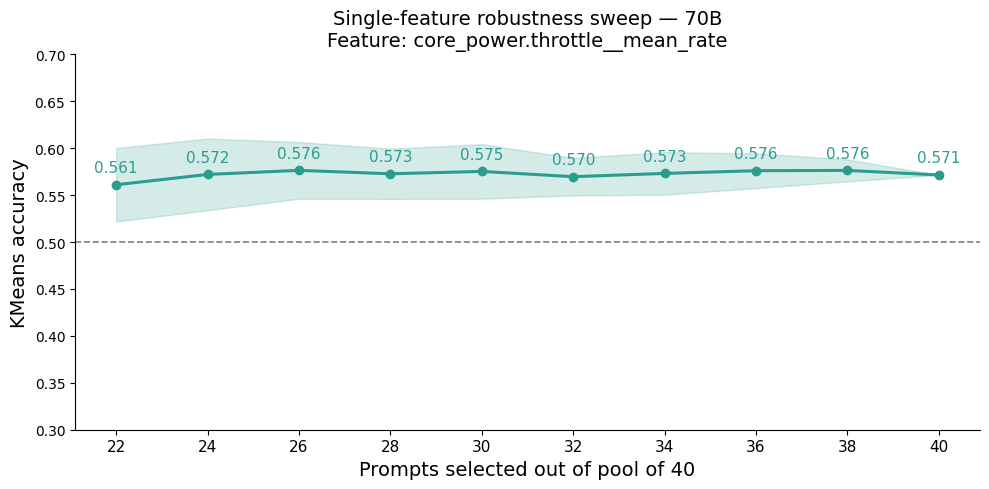

Saved: /Users/rsalvi/Desktop/mccviahat/results/hat_analysis/single_feature_robustness_70b.png


In [16]:
COLOR = '#2a9d8f'

xs   = res['x'].values
mean = res['mean_acc'].values
std  = res['std_acc'].values

fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(xs, mean, marker='o', lw=2.2, color=COLOR, zorder=3,
        label=f'Best feature: {BEST_FEATURE}')
ax.fill_between(xs, mean - std, mean + std,
                alpha=0.20, color=COLOR, label='± 1 SD across 20 repeats')

for xi, mi in zip(xs, mean):
    ax.annotate(f'{mi:.3f}', (xi, mi),
                textcoords='offset points', xytext=(0, 9),
                ha='center', fontsize=11, color=COLOR)

ax.axhline(0.5, color='grey', lw=1.2, ls='--', label='Chance (0.50)')

ax.set_xlabel('Prompts selected out of pool of 40', fontsize=14)
ax.set_ylabel('KMeans accuracy', fontsize=14)
ax.set_title(
    f'Single-feature robustness sweep — 70B\n'
    f'Feature: {BEST_FEATURE}',
    fontsize=14
)
ax.set_xticks(xs)
ax.set_xticklabels([str(xi) for xi in xs], fontsize=11)
ax.set_ylim(0.3, 0.7)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out = RESULT_DIR / 'single_feature_robustness_70b.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## §7 — Summary table

In [9]:
print('Single-feature robustness sweep — 7B')
print(f'Best feature: {BEST_FEATURE}')
print(f'Full-dataset accuracy (x=40): {res[res.x==40].mean_acc.values[0]:.4f}')
print()
print(f'  {"x":>4}  {"total":>6}  {"mean acc":>9}  {"± SD":>7}  {"mean ARI":>9}  {"± SD":>7}')
print('-' * 60)
for _, r in res.iterrows():
    print(f'  {int(r.x):>4}  {int(r.total):>6}  {r.mean_acc:>9.4f}  '
          f'{r.std_acc:>7.4f}  {r.mean_ari:>9.4f}  {r.std_ari:>7.4f}')
print()
print(f'Chance baseline: 0.5000')

Single-feature robustness sweep — 7B
Best feature: core_power.throttle__mean_rate
Full-dataset accuracy (x=40): 0.5714

     x   total   mean acc     ± SD   mean ARI     ± SD
------------------------------------------------------------
    22     154     0.5610   0.0391     0.0147   0.0231
    24     168     0.5720   0.0382     0.0208   0.0219
    26     182     0.5764   0.0302     0.0216   0.0204
    28     196     0.5727   0.0268     0.0190   0.0140
    30     210     0.5752   0.0291     0.0214   0.0202
    32     224     0.5696   0.0200     0.0166   0.0105
    34     238     0.5731   0.0226     0.0193   0.0139
    36     252     0.5760   0.0185     0.0206   0.0117
    38     266     0.5763   0.0117     0.0202   0.0073
    40     280     0.5714   0.0000     0.0169   0.0000

Chance baseline: 0.5000


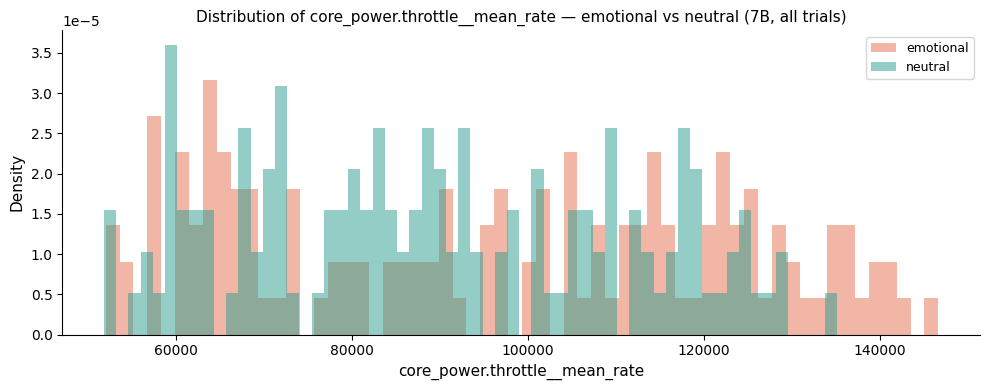

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

for cond, color in [('emotional', '#e76f51'), ('neutral', '#2a9d8f')]:
    vals = df_all[df_all.condition == cond][BEST_FEATURE].dropna().values
    ax.hist(vals, bins=60, alpha=0.5, color=color, label=cond, density=True)

ax.set_xlabel(BEST_FEATURE, fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Distribution of {BEST_FEATURE} — emotional vs neutral (7B, all trials)', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()